# AI FRAUD DETECTION SYSTEM

### 1.IMPORTING DEPENDENCIES

In [8]:
# import libraries
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Machine Learning
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    average_precision_score,
    precision_recall_curve
)

# Preprocessing
from sklearn.preprocessing import RobustScaler
from sklearn.compose import ColumnTransformer

# Pipeline
from imblearn.pipeline import Pipeline

# SMOTE
from imblearn.over_sampling import SMOTE

# Models
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

# Saving model
import joblib

print("Libraries Imported Successfully")

Libraries Imported Successfully


### 2. LOAD DATASET

In [11]:
df = pd.read_csv("creditcard.csv")
print("Dataset Loaded Successfully")


Dataset Loaded Successfully


In [12]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,V11,V12,V13,V14,V15,V16,V17,V18,V19,V20,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,-0.551600,-0.617801,-0.991390,-0.311169,1.468177,-0.470401,0.207971,0.025791,0.403993,0.251412,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,1.612727,1.065235,0.489095,-0.143772,0.635558,0.463917,-0.114805,-0.183361,-0.145783,-0.069083,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,0.624501,0.066084,0.717293,-0.165946,2.345865,-2.890083,1.109969,-0.121359,-2.261857,0.524980,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,-0.226487,0.178228,0.507757,-0.287924,-0.631418,-1.059647,-0.684093,1.965775,-1.232622,-0.208038,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,-0.822843,0.538196,1.345852,-1.119670,0.175121,-0.451449,-0.237033,-0.038195,0.803487,0.408542,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


In [14]:
df.shape

(284807, 31)

### 3. BASIC DATA UNDERSTANDING

In [15]:
print("\nMissing Values:")
print(df.isnull().sum())


Missing Values:
Time      0
V1        0
V2        0
V3        0
V4        0
V5        0
V6        0
V7        0
V8        0
V9        0
V10       0
V11       0
V12       0
V13       0
V14       0
V15       0
V16       0
V17       0
V18       0
V19       0
V20       0
V21       0
V22       0
V23       0
V24       0
V25       0
V26       0
V27       0
V28       0
Amount    0
Class     0
dtype: int64


In [16]:
print("\nTarget Distribution:")
print(df['Class'].value_counts())



Target Distribution:
Class
0    284315
1       492
Name: count, dtype: int64


In [17]:
fraud_ratio = df['Class'].mean()

print("\nFraud Ratio:")
print(fraud_ratio)


Fraud Ratio:
0.001727485630620034


### 4. EXPLORATORY DATA ANALYSIS (EDA)
  **Fraud vs Non-Fraud Distribution**

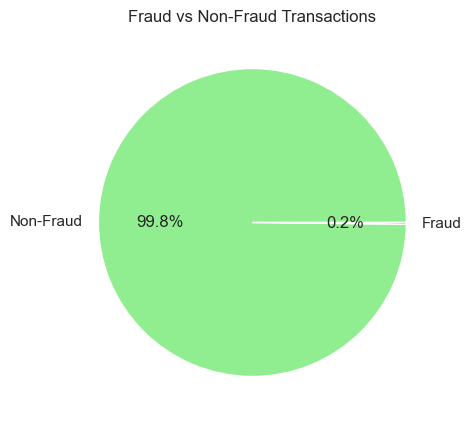

In [19]:
# Pie chart
plt.figure(figsize=(5,5))
plt.pie(df['Class'].value_counts().values, labels=['Non-Fraud', 'Fraud'], autopct='%1.1f%%', colors=['lightgreen', 'red'])
plt.title('Fraud vs Non-Fraud Transactions')
plt.show()


**Transaction Amount Distribution**

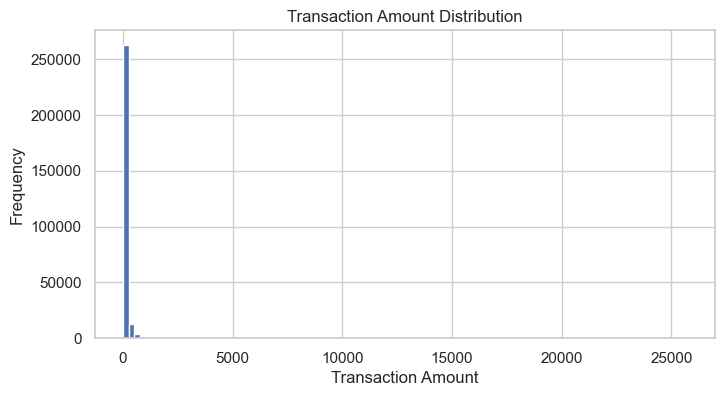

In [20]:
plt.figure(figsize=(8,4))

plt.hist(df['Amount'], bins=100)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()


**Create Hour Feature from Time**

In [21]:
# Time is in seconds
# Convert seconds into hours

df['Hour'] = (df['Time'] // 3600) % 24

**Transactions by Hour**

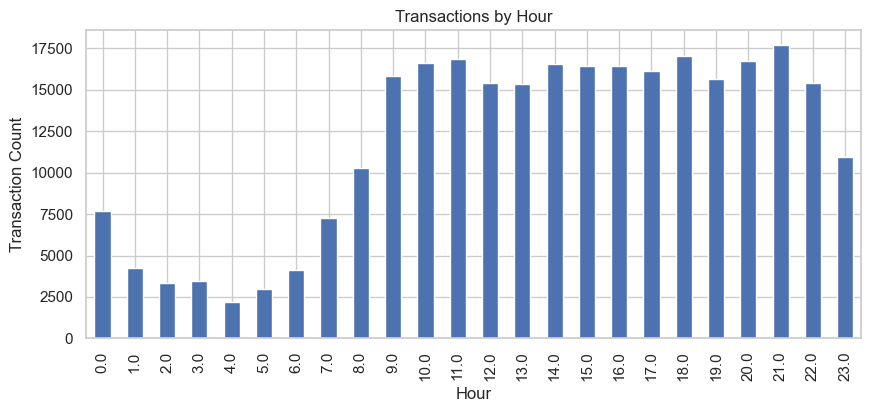

In [22]:
plt.figure(figsize=(10,4))

df.groupby('Hour').size().plot(kind='bar')

plt.title("Transactions by Hour")
plt.xlabel("Hour")
plt.ylabel("Transaction Count")

plt.show()

### 5. FEATURE ENGINEERING
Feature engineering means:
Creating new useful features from existing data

**A. Log Amount**

In [23]:
# Transaction amounts are heavily skewed
# Log transformation reduces extreme effects

df['log_amount'] = np.log1p(df['Amount'])


**B. Amount to Mean Ratio**

In [24]:
# Helps identify unusually large transactions

global_mean = df['Amount'].mean()

df['amount_to_mean'] = (
    df['Amount'] / global_mean
)



**C. High Amount Transaction Flag**

In [25]:
# Mark top 1% highest transactions

p99 = df['Amount'].quantile(0.99)

df['is_high_amount'] = (
    df['Amount'] > p99
).astype(int)

**D. Night Transaction Feature**

In [26]:
# Fraud often occurs during unusual hours

df['is_night'] = df['Hour'].isin(
    [0,1,2,3,4,5,22,23]
).astype(int)

### 6. FEATURES AND TARGET

In [27]:
X = df.drop('Class', axis=1)

y = df['Class']

print("\nFeature Shape:", X.shape)
print("Target Shape:", y.shape)



Feature Shape: (284807, 35)
Target Shape: (284807,)


### 7. TRAIN TEST SPLIT

In [28]:
# Stratify maintains fraud ratio in train and test sets

X_train, X_test, y_train, y_test = train_test_split(
    
    X,
    y,
    
    test_size=0.2,
    
    stratify=y,
    
    random_state=42
)

print("\nTrain Shape:", X_train.shape)
print("Test Shape:", X_test.shape)


Train Shape: (227845, 35)
Test Shape: (56962, 35)


### 8. PREPROCESSING

In [29]:
# Since all columns are numerical,
# we apply RobustScaler

# RobustScaler handles outliers better

numeric_features = X.columns.tolist()


preprocessor = ColumnTransformer([
    
    (
        'num',
        RobustScaler(),
        numeric_features
    )
])

### 9. CREATE PIPELINES
Pipeline automatically performs:
 1. Scaling
 2. SMOTE balancing
 3. Model training

**Logistic Regression Pipeline**

In [30]:
lr_pipeline = Pipeline([
    
    ('preprocessing', preprocessor),

    ('smote', SMOTE(random_state=42)),

    ('model', LogisticRegression(
        max_iter=1000
    ))
])

**Random Forest Pipeline**


In [31]:
rf_pipeline = Pipeline([
    
    ('preprocessing', preprocessor),

    ('smote', SMOTE(random_state=42)),

    ('model', RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ))
])

**XGBoost Pipeline**

In [32]:
xgb_pipeline = Pipeline([
    
    ('preprocessing', preprocessor),

    ('smote', SMOTE(random_state=42)),

    ('model', XGBClassifier(
        
        eval_metric='logloss',
        
        random_state=42,
        
        scale_pos_weight=(
            len(y_train[y_train==0]) /
            len(y_train[y_train==1])
        )
    ))
])


### 10. TRAIN MODELS

In [33]:
trained_models = {
    
    'Logistic Regression': lr_pipeline,
    
    'Random Forest': rf_pipeline,
    
    'XGBoost': xgb_pipeline
}

In [34]:
for name, pipeline in trained_models.items():
    
    print(f"\nTraining {name}...")
    
    pipeline.fit(X_train, y_train)
    
    print(f"{name} Trained Successfully")


Training Logistic Regression...
Logistic Regression Trained Successfully

Training Random Forest...
Random Forest Trained Successfully

Training XGBoost...
XGBoost Trained Successfully


### 11. MODEL EVALUATION FUNCTION

In [36]:
def evaluate_model(model, X_test, y_test):
    
    # Predict probabilities
    
    y_scores = model.predict_proba(X_test)[:,1]
    
    # Default threshold = 0.5
    
    y_pred = (y_scores >= 0.5).astype(int)

In [ ]:

 # Metrics
   
    
print("\nClassification Report:")
    
def evaluate_model(model, X_test, y_test):
    # Predict probabilities
    y_scores = model.predict_proba(X_test)[:, 1]
    # Default threshold = 0.5
    y_pred = (y_scores >= 0.5).astype(int)

    # Metrics
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred, digits=4))

    # ROC-AUC
    roc = roc_auc_score(y_test, y_scores)
    print("ROC-AUC:", roc)

    # Average Precision
    ap = average_precision_score(y_test, y_scores)
    print("Average Precision:", ap)

    return {"y_pred": y_pred, "y_scores": y_scores, "roc_auc": roc, "average_precision": ap}   
roc = roc_auc_score(y_test, y_scores)
    
print("ROC-AUC:", roc)
    
    
    # Average Precision
    def evaluate_model(model, X_test, y_test):
        y_scores = model.predict_proba(X_test)[:, 1]
        y_pred = (y_scores >= 0.5).astype(int)

        print("\nClassification Report:")
        print(classification_report(y_test, y_pred, digits=4))

        roc = roc_auc_score(y_test, y_scores)
        print("ROC-AUC:", roc)

        ap = average_precision_score(y_test, y_scores)
        print("Average Precision:", ap)

        return {"y_pred": y_pred, "y_scores": y_scores, "roc_auc": roc, "average_precision": ap}   
print("Average Precision:", ap)


Classification Report:


NameError: name 'y_pred' is not defined